# Bước 3 — Kiểm định độ tin cậy Cronbach Alpha
**Input:** `data_sach.csv`  
**Output:** Bảng Cronbach Alpha + Item-Total Correlation → quyết định giữ/loại item trước EFA

---
### Tiêu chí đánh giá
| Alpha | Đánh giá |
|-------|----------|
| ≥ 0.9 | Xuất sắc |
| 0.8 – 0.9 | Tốt |
| 0.7 – 0.8 | Chấp nhận được |
| < 0.7 | Thấp → cần xem xét loại item |

**Item-Total Correlation (CITC):** ≥ 0.3 → giữ, < 0.3 → cân nhắc loại  
**Alpha if Item Deleted:** nếu xóa item mà alpha tăng > 0.01 → nên loại

In [ ]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130
print('Sẵn sàng!')

Sẵn sàng!


In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f'N = {len(df)}')

Saving data_sach (1).csv to data_sach (1).csv
N = 193


In [ ]:
groups = {
    'EE':  [f'EE{i}'  for i in range(1,6)],
    'PE':  [f'PE{i}'  for i in range(1,6)],
    'SI':  [f'SI{i}'  for i in range(1,6)],
    'FC':  [f'FC{i}'  for i in range(1,6)],
    'RA':  [f'RA{i}'  for i in range(1,6)],
    'ANX': [f'ANX{i}' for i in range(1,6)],
    'BI':  [f'BI{i}'  for i in range(1,6)],
}
group_labels = {
    'EE':  'Effort Expectancy',
    'PE':  'Performance Expectancy',
    'SI':  'Social Influence',
    'FC':  'Facilitating Conditions',
    'RA':  'Responsible AI Awareness',
    'ANX': 'AI Anxiety',
    'BI':  'Behavioral Intention',
}
print('Định nghĩa nhóm biến xong!')

Định nghĩa nhóm biến xong!


---
## 1. Hàm tính Cronbach Alpha & các chỉ số

In [ ]:
def cronbach_alpha(df_items):
    """Tính Cronbach Alpha chuẩn (công thức standardized)"""
    df_items = df_items.dropna()
    n = df_items.shape[1]
    if n < 2:
        return np.nan
    item_vars  = df_items.var(axis=0, ddof=1)
    total_var  = df_items.sum(axis=1).var(ddof=1)
    return (n / (n - 1)) * (1 - item_vars.sum() / total_var)


def item_total_corr(df_items):
    """Corrected Item-Total Correlation (CITC)"""
    citc = {}
    for col in df_items.columns:
        rest   = df_items.drop(columns=[col]).sum(axis=1)
        citc[col] = round(df_items[col].corr(rest), 4)
    return citc


def alpha_if_deleted(df_items):
    """Alpha nếu loại từng item"""
    aid = {}
    for col in df_items.columns:
        remaining  = df_items.drop(columns=[col])
        aid[col]   = round(cronbach_alpha(remaining), 4)
    return aid


print('Hàm đã định nghĩa xong!')

Hàm đã định nghĩa xong!


---
## 2. Chạy Cronbach Alpha cho 7 nhóm

In [ ]:
all_results = []
summary_rows = []

for g, cols in groups.items():
    df_g    = df[cols].copy()
    alpha   = cronbach_alpha(df_g)
    citc    = item_total_corr(df_g)
    aid     = alpha_if_deleted(df_g)

    print(f'\n═══ {g} — {group_labels[g]} ═══')
    print(f'  Cronbach Alpha = {alpha:.4f}', end='  ')
    if   alpha >= 0.9: print('→ Xuất sắc ✅')
    elif alpha >= 0.8: print('→ Tốt ✅')
    elif alpha >= 0.7: print('→ Chấp nhận được ⚠️')
    else:              print('→ Thấp ❌')

    print(f'  {"Item":<8} {"Mean":>6} {"SD":>6} {"CITC":>7} {"Alpha if deleted":>16} {"Ghi chú"}')
    print(f'  {"-"*65}')

    for col in cols:
        mean_v = df_g[col].mean()
        sd_v   = df_g[col].std()
        c_val  = citc[col]
        a_val  = aid[col]
        note   = ''
        if c_val < 0.3:         note += 'CITC thấp ⚠️ '
        if a_val > alpha + 0.01: note += 'Nên loại 🔴'

        print(f'  {col:<8} {mean_v:>6.3f} {sd_v:>6.3f} {c_val:>7.4f} {a_val:>16.4f}  {note}')

        all_results.append({
            'Nhóm': g, 'Tên nhóm': group_labels[g],
            'Item': col, 'Mean': round(mean_v,3), 'SD': round(sd_v,3),
            'CITC': c_val, 'Alpha_if_deleted': a_val,
            'Alpha_nhóm': round(alpha,4),
            'Ghi chú': note.strip()
        })

    summary_rows.append({
        'Nhóm': g, 'Construct': group_labels[g],
        'N items': len(cols),
        'Alpha': round(alpha, 4),
        'Đánh giá': 'Xuất sắc' if alpha>=0.9 else ('Tốt' if alpha>=0.8 else ('Chấp nhận' if alpha>=0.7 else 'Thấp'))
    })

df_all   = pd.DataFrame(all_results)
df_summ  = pd.DataFrame(summary_rows)


═══ EE — Effort Expectancy ═══
  Cronbach Alpha = 0.8028  → Tốt ✅
  Item       Mean     SD    CITC Alpha if deleted Ghi chú
  -----------------------------------------------------------------
  EE1       3.606  1.177  0.6262           0.7521  
  EE2       3.731  1.104  0.5424           0.7781  
  EE3       3.482  1.151  0.6011           0.7603  
  EE4       3.373  1.157  0.5830           0.7660  
  EE5       3.715  1.176  0.5778           0.7677  

═══ PE — Performance Expectancy ═══
  Cronbach Alpha = 0.8603  → Tốt ✅
  Item       Mean     SD    CITC Alpha if deleted Ghi chú
  -----------------------------------------------------------------
  PE1       3.674  1.209  0.7060           0.8239  
  PE2       3.518  1.225  0.6924           0.8275  
  PE3       3.451  1.233  0.6614           0.8356  
  PE4       3.855  1.141  0.6909           0.8283  
  PE5       3.736  1.185  0.6392           0.8409  

═══ SI — Social Influence ═══
  Cronbach Alpha = 0.8313  → Tốt ✅
  Item       Mean     S

---
## 3. Bảng tổng hợp Alpha các nhóm

In [ ]:
print('\n=== BẢNG TỔNG HỢP CRONBACH ALPHA ===')
print(df_summ.to_string(index=False))

items_to_review = df_all[df_all['Ghi chú'] != '']
if len(items_to_review) > 0:
    print('\n=== ITEM CẦN XEM XÉT ===')
    print(items_to_review[['Nhóm','Item','CITC','Alpha_if_deleted','Alpha_nhóm','Ghi chú']].to_string(index=False))
else:
    print('\n✅ Tất cả item đều đạt tiêu chí — không cần loại item nào!')


=== BẢNG TỔNG HỢP CRONBACH ALPHA ===
Nhóm                Construct  N items  Alpha  Đánh giá
  EE        Effort Expectancy        5 0.8028       Tốt
  PE   Performance Expectancy        5 0.8603       Tốt
  SI         Social Influence        5 0.8313       Tốt
  FC  Facilitating Conditions        5 0.7781 Chấp nhận
  RA Responsible AI Awareness        5 0.8064       Tốt
 ANX               AI Anxiety        5 0.8083       Tốt
  BI     Behavioral Intention        5 0.8199       Tốt

✅ Tất cả item đều đạt tiêu chí — không cần loại item nào!


---
## 4. Biểu đồ Alpha các nhóm

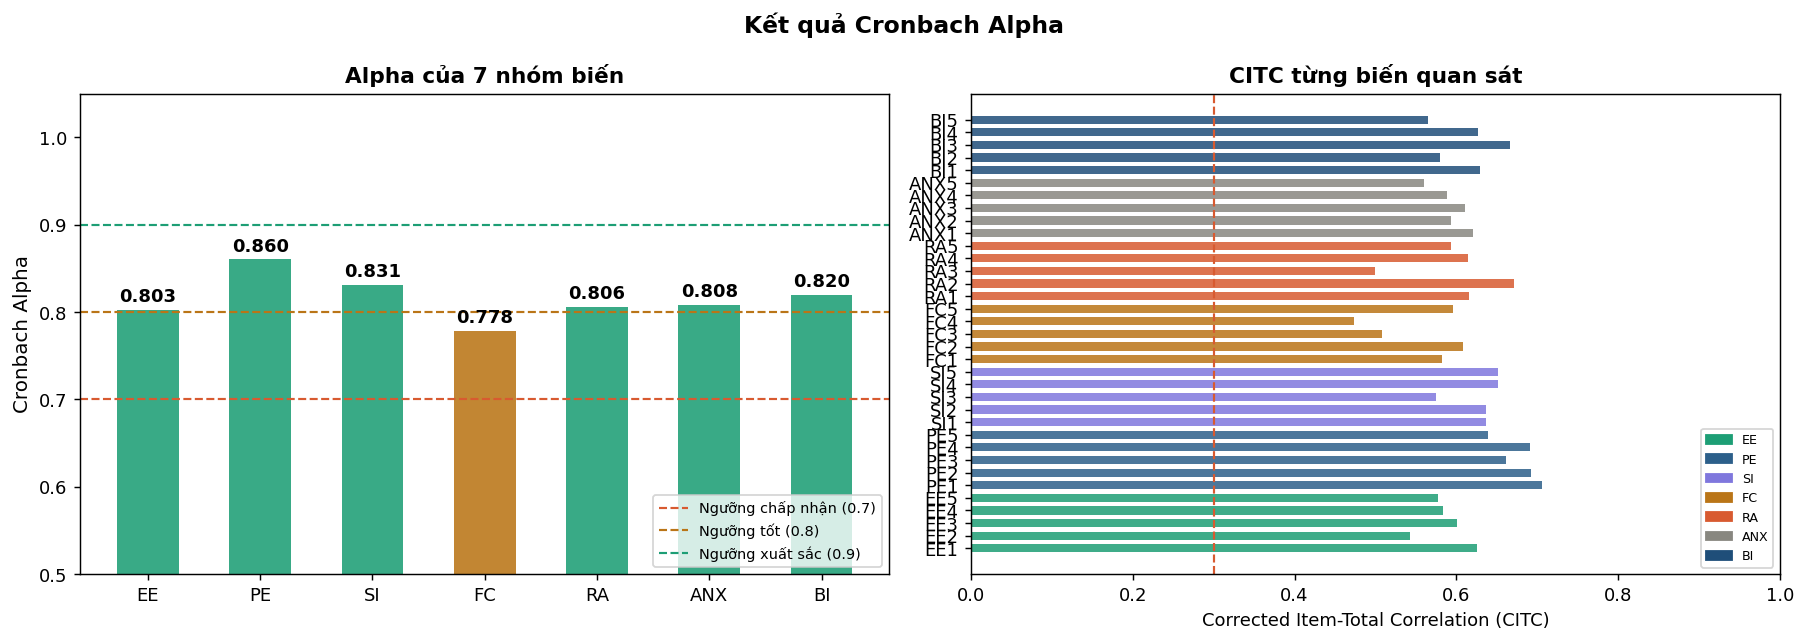

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kết quả Cronbach Alpha', fontweight='bold', fontsize=13)

# --- Biểu đồ 1: Alpha từng nhóm ---
ax = axes[0]
g_keys   = list(groups.keys())
alphas   = [cronbach_alpha(df[groups[g]]) for g in g_keys]
bar_cols = ['#D85A30' if a < 0.7 else ('#BA7517' if a < 0.8 else '#1D9E75')
            for a in alphas]

bars = ax.bar(g_keys, alphas, color=bar_cols, width=0.55, alpha=0.88)
ax.axhline(0.7, color='#D85A30', linestyle='--', linewidth=1.2, label='Ngưỡng chấp nhận (0.7)')
ax.axhline(0.8, color='#BA7517', linestyle='--', linewidth=1.2, label='Ngưỡng tốt (0.8)')
ax.axhline(0.9, color='#1D9E75', linestyle='--', linewidth=1.2, label='Ngưỡng xuất sắc (0.9)')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Cronbach Alpha', fontsize=11)
ax.set_title('Alpha của 7 nhóm biến', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
for bar, val in zip(bars, alphas):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Biểu đồ 2: CITC từng item, tô màu theo nhóm ---
ax2 = axes[1]
group_colors = {
    'EE':'#1D9E75','PE':'#2C5F8A','SI':'#7F77DD',
    'FC':'#BA7517','RA':'#D85A30','ANX':'#888780','BI':'#1F4E79'
}
items_all = df_all['Item'].tolist()
citc_all  = df_all['CITC'].tolist()
cols_all  = [group_colors[df_all.loc[i,'Nhóm']] for i in df_all.index]

ax2.barh(items_all, citc_all, color=cols_all, alpha=0.85, height=0.65)
ax2.axvline(0.3, color='#D85A30', linestyle='--', linewidth=1.2, label='Ngưỡng CITC (0.3)')
ax2.set_xlabel('Corrected Item-Total Correlation (CITC)', fontsize=10)
ax2.set_title('CITC từng biến quan sát', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1)

# Legend nhóm
patches = [mpatches.Patch(color=v, label=k) for k,v in group_colors.items()]
ax2.legend(handles=patches, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('cronbach_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Quyết định giữ/loại item & xuất data cập nhật

In [ ]:
# ── Dựa trên kết quả phân tích ở trên, điền vào đây các item cần loại ──
# Quy tắc: chỉ loại khi CITC < 0.3 HOẶC Alpha_if_deleted tăng > 0.01
# Để trống nếu không loại item nào

items_to_drop = []  # Ví dụ: ['SI3', 'FC4'] — điền sau khi xem kết quả ở trên

# ─────────────────────────────────────────────────────────────────────────

if items_to_drop:
    df_final = df.drop(columns=items_to_drop)
    print(f'Đã loại {len(items_to_drop)} item: {items_to_drop}')

    # Tính lại alpha sau khi loại
    print('\nAlpha sau khi loại:')
    for g, cols in groups.items():
        remaining = [c for c in cols if c not in items_to_drop]
        if len(remaining) >= 2:
            a = cronbach_alpha(df_final[remaining])
            print(f'  {g}: α = {a:.4f}  ({len(remaining)} items còn lại)')
else:
    df_final = df.copy()
    print('Giữ nguyên tất cả item — không loại gì.')

df_final.to_csv('data_sau_cronbach.csv', index=False, encoding='utf-8-sig')
print(f'\nXuất: data_sau_cronbach.csv  (N={len(df_final)})')

Giữ nguyên tất cả item — không loại gì.

Xuất: data_sau_cronbach.csv  (N=193)


In [ ]:
# Xuất bảng kết quả ra Excel
with pd.ExcelWriter('cronbach_alpha_results.xlsx', engine='openpyxl') as writer:
    df_summ.to_excel(writer, sheet_name='Tong_hop_alpha', index=False)
    df_all.to_excel(writer,  sheet_name='Chi_tiet_item',  index=False)

print('Xuất xong: cronbach_alpha_results.xlsx')

for f in ['cronbach_alpha_results.xlsx', 'data_sau_cronbach.csv', 'cronbach_alpha.png']:
    files.download(f)

print('\n=== TÓM TẮT KẾT QUẢ ===')
for _, row in df_summ.iterrows():
    icon = '✅' if row['Alpha'] >= 0.7 else '❌'
    print(f"  {icon} {row['Nhóm']}: α = {row['Alpha']}  → {row['Đánh giá']}")

print('\nBước tiếp theo → Bước 4: EFA (Exploratory Factor Analysis)')

Xuất xong: cronbach_alpha_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== TÓM TẮT KẾT QUẢ ===
  ✅ EE: α = 0.8028  → Tốt
  ✅ PE: α = 0.8603  → Tốt
  ✅ SI: α = 0.8313  → Tốt
  ✅ FC: α = 0.7781  → Chấp nhận
  ✅ RA: α = 0.8064  → Tốt
  ✅ ANX: α = 0.8083  → Tốt
  ✅ BI: α = 0.8199  → Tốt

Bước tiếp theo → Bước 4: EFA (Exploratory Factor Analysis)
